# First Variational Autoencoder

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from keras import regularizers

In [2]:
# CONFIG
LATENT_DIM  = 128
EPOCHS      = 50
BATCH_SIZE  = 64
BETA        = 0.01        # KL weight (1 = standard VAE)
NEGATIVE_SLOPE = 0.2 # LeakyReLU negative slope

## Load the data

In [3]:
def load_data():
    x_train = np.load('../data/processed/x_train.npy')
    x_test  = np.load('../data/processed/x_test.npy')
    return x_train, x_test

x_train, x_test = load_data()

image_shape = x_train.shape[1:]
print(f"Image shape: {image_shape}")

Image shape: (100, 100, 3)


In [4]:
x_train.shape, x_test.shape

((168, 100, 100, 3), (43, 100, 100, 3))

## Normalization

In [5]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


## Variational Autoencoder

In [6]:
class Sampling(layers.Layer):
    def call(self, inputs):
        """z = z_mean + exp(0.5 * z_log_var) * epsilon"""
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [7]:
L2          = 1e-4
DROPOUT     = 0.3

def build_encoder(image_shape, latent_dim):
    encoder_input = keras.Input(shape=image_shape, name='encoder_input')

    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu',)(x)
    x = layers.Dropout(DROPOUT)(x)

    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])

    encoder = keras.Model(encoder_input, [mu, log_var, z], name='encoder')
    encoder.summary()
    return encoder


def build_decoder(image_shape, latent_dim):
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(25 * 25 * 128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2))(decoder_input)
    x = layers.Reshape((25, 25, 128))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    x = layers.Conv2DTranspose(64, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    decoder_output = layers.Conv2DTranspose(
        image_shape[2], 3,
        activation='sigmoid',
        padding='same',
        name='decoder_output'
    )(x)

    decoder = keras.Model(decoder_input, decoder_output, name='decoder')
    decoder.summary()
    return decoder


class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -4.0, 4.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta

        self.total_loss_tracker          = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker             = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, x):
        mu, log_var, z = self.encoder(x)
        log_var   = tf.clip_by_value(log_var, -4.0, 4.0)  # numerical stability
        z_decoded = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(x - z_decoded),
                axis=(1, 2, 3)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1.0 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

In [8]:
encoder = build_encoder(image_shape, LATENT_DIM)
decoder = build_decoder(image_shape, LATENT_DIM)
vae = VAE(encoder, decoder, beta=BETA)

2026-02-24 21:32:17.480687: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-02-24 21:32:17.480720: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-24 21:32:17.480727: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-24 21:32:17.480760: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-24 21:32:17.480770: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 50, 50,    │        864 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 50,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 25, 25,    │     18,432 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 13, 13,    │     73,728 │ activation_1[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 21632)     │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │ 11,076,096 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 128)       │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,301,344 (43.11 MB)

 Trainable params: 11,300,896 (43.11 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80000)          │    10,320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 50, 50, 128)    │       147,456 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 100, 100, 32)   │        18,432 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 100, 100, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561,379 (40.29 MB)

 Trainable params: 10,560,931 (40.29 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
def train_vae(vae: VAE, x_train):
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_total_loss", 
            patience=25,
            restore_best_weights=True, 
            mode='min',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_total_loss", 
            patience=5,
            factor=0.5, 
            min_lr=1e-6, 
            mode='min',
            verbose=1
        ),
    ]

    history = vae.fit(
        x_train, x_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
    )
    return history

In [10]:
history = train_vae(vae, x_train)

Epoch 1/50


2026-02-24 21:32:18.443442: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - kl_loss: 272.5047 - reconstruction_loss: 5523.4688 - total_loss: 5526.1938 - val_kl_loss: 3587.1250 - val_reconstruction_loss: 2984.1670 - val_total_loss: 3020.0383 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - kl_loss: 14720.9404 - reconstruction_loss: 2250.4690 - total_loss: 2397.6785 - val_kl_loss: 30666.8516 - val_reconstruction_loss: 1582.6837 - val_total_loss: 1889.3523 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - kl_loss: 23383.8203 - reconstruction_loss: 1584.3104 - total_loss: 1818.1484 - val_kl_loss: 10099.0391 - val_reconstruction_loss: 1358.2900 - val_total_loss: 1459.2804 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - kl_loss: 6386.0845 - reconstruction_loss: 1367.5972 - total_loss: 1431.4581 - val_kl_loss: 2170.7207 - val_reconstruction_loss: 1344.8435 - val_total_loss: 1366.5507 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [11]:
def plot_history(history: keras.callbacks.History,
                 save_path: str = "../reports/figures/training_history.png"):
    tracked = [
        ("total_loss",          "Total Loss"),
        ("reconstruction_loss", "Reconstruction Loss"),
        ("kl_loss",             "KL Loss"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("VAE Training History", fontsize=14)

    for ax, (key, title) in zip(axes, tracked):
        ax.plot(history.history[key],            label="Train")
        ax.plot(history.history[f"val_{key}"],   label="Validation")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"History plot saved to {save_path}")

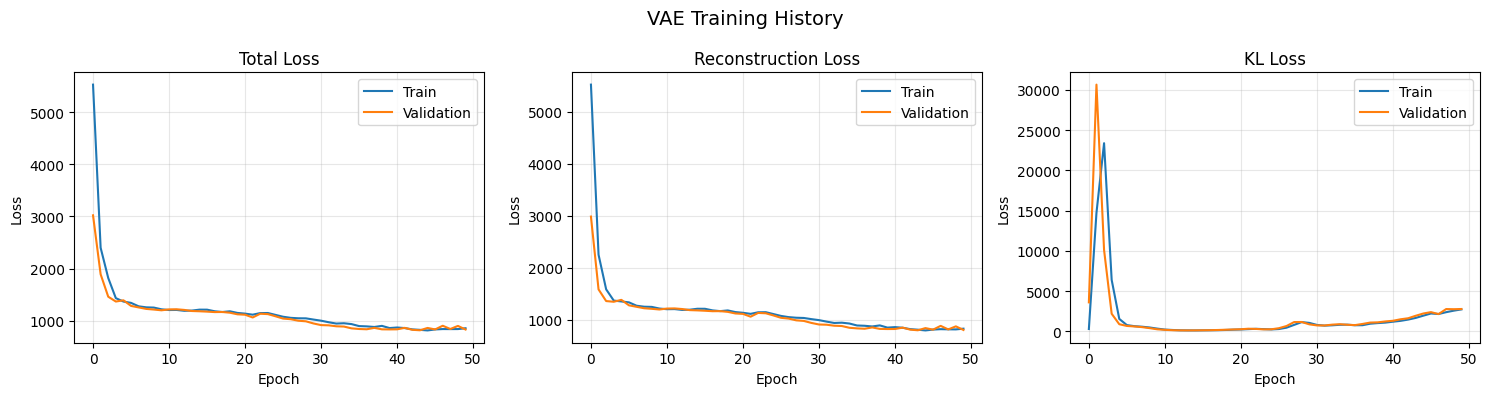

History plot saved to ../reports/figures/training_history.png


In [12]:
plot_history(history)

In [13]:
def evaluate_on_test(
    vae: VAE,
    decoder: keras.Model,
    x_test: np.ndarray,
    n_show: int = 5,
    save_path: str = "../reports/figures/test_reconstructions.png",
):
    print("\n── Test Set Evaluation ──")
    results = vae.evaluate(x_test, x_test, batch_size=BATCH_SIZE, verbose=1)
    print(f"  total_loss:          {results[0]:.4f}")
    print(f"  reconstruction_loss: {results[1]:.4f}")
    print(f"  kl_loss:             {results[2]:.4f}")

    # Reconstruct images
    n_show = min(n_show, len(x_test))
    samples = x_test[:n_show]
    mu, log_var, z = vae.encoder.predict(samples, verbose=0)
    reconstructed  = decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 5))
    fig.suptitle("Top: Original  |  Bottom: Reconstructed", fontsize=11)

    for i in range(n_show):
        axes[0, i].imshow(np.clip(samples[i], 0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Reconstructions saved to {save_path}")


── Test Set Evaluation ──
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - kl_loss: 1787.4644 - reconstruction_loss: 805.3912 - total_loss: 823.2658
  total_loss:          823.2658
  reconstruction_loss: 805.3912
  kl_loss:             1787.4644


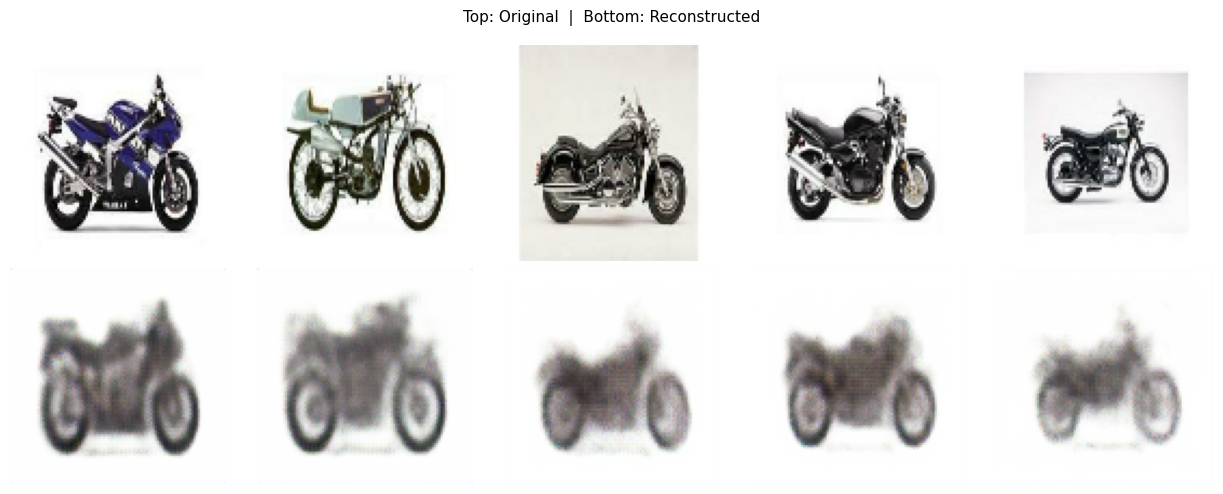

Reconstructions saved to ../reports/figures/test_reconstructions.png


In [14]:
evaluate_on_test(vae, decoder, x_test)

In [15]:
def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"../reports/figures/generated_images_{n_images}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Generated images saved to {save_path}")


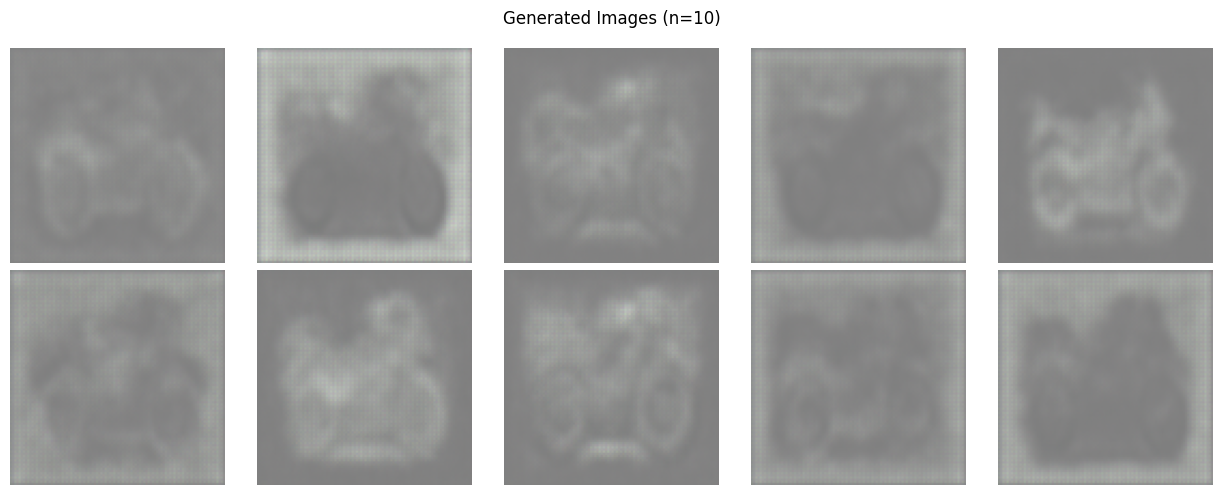

Generated images saved to ../reports/figures/generated_images_10.png


In [16]:
generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)